# Predição de Aprovação Escolar

Este notebook realiza análise exploratória, tratamento de dados, modelagem e avaliação para prever a aprovação de estudantes com base em dados de desempenho escolar.

## Tratamento dos dados

### Inicialização e Importações 

In [2]:
# Bibliotecas de manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de machine learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Bibliotecas de balanceamento de classes
#from imblearn.over_sampling import SMOTE
from collections import Counter

# Configuração de gráficos
sns.set_palette('husl')
%matplotlib inline

In [3]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

from sklearn import __version__ as skl_version
print("scikit-learn:", skl_version)

pandas: 1.5.3
numpy: 1.23.5
matplotlib: 3.7.1
seaborn: 0.12.2
scikit-learn: 1.2.2


### Carregamento dos Dados

In [4]:
# Altere o caminho se necessário
df_mat = pd.read_csv('dados/raw/student-mat.csv', sep=';')
df_por = pd.read_csv('dados/raw/student-por.csv', sep=';')

print('Dimensões dos dados de matemática:', df_mat.shape)
print('Dimensões dos dados de português:', df_por.shape)

Dimensões dos dados de matemática: (395, 33)
Dimensões dos dados de português: (649, 33)


### Análise Exploratória

In [5]:
#Visualização Inicial

print('Primeiras linhas dos dados de matemática:')
display(df_mat.head())

print('\nPrimeiras linhas dos dados de português:')
display(df_por.head())

print('\nEstatísticas descritivas dos dados de matemática:')
display(df_mat.describe())

print('\nEstatísticas descritivas dos dados de português:')
display(df_por.describe())

print('\nValores ausentes nos dados de matemática:')
print(df_mat.isnull().sum())

print('\nValores ausentes nos dados de português:')
print(df_por.isnull().sum())

Primeiras linhas dos dados de matemática:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Primeiras linhas dos dados de português:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Estatísticas descritivas dos dados de matemática:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



Estatísticas descritivas dos dados de português:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000



Valores ausentes nos dados de matemática:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Valores ausentes nos dados de português:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel

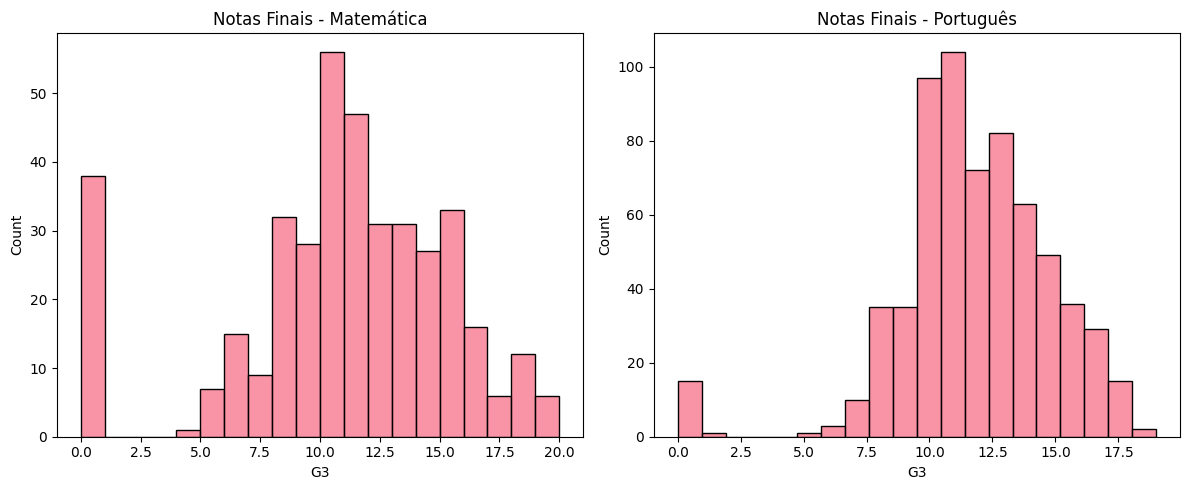

In [6]:
#Visualização Gráfica

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_mat['G3'], bins=20)
plt.title('Notas Finais - Matemática')
plt.subplot(1, 2, 2)
sns.histplot(df_por['G3'], bins=20)
plt.title('Notas Finais - Português')
plt.tight_layout()
plt.show()

In [10]:
#Tradução de colunas

traducao = {
    'age': 'idade',
    'Medu': 'escolaridade_mae',
    'Fedu': 'escolaridade_pai',
    'traveltime': 'tempo_viagem',
    'studytime': 'tempo_estudo',
    'failures': 'reprovações',
    'famrel': 'relacao_familiar',
    'freetime': 'tempo_livre',
    'goout': 'sair_com_amigos',
    'Dalc': 'alcool_dia',
    'Walc': 'alcool_fim_semana',
    'health': 'saude',
    'absences': 'faltas',
    'G1': 'nota_1',
    'G2': 'nota_2',
    'G3': 'nota_final'
}

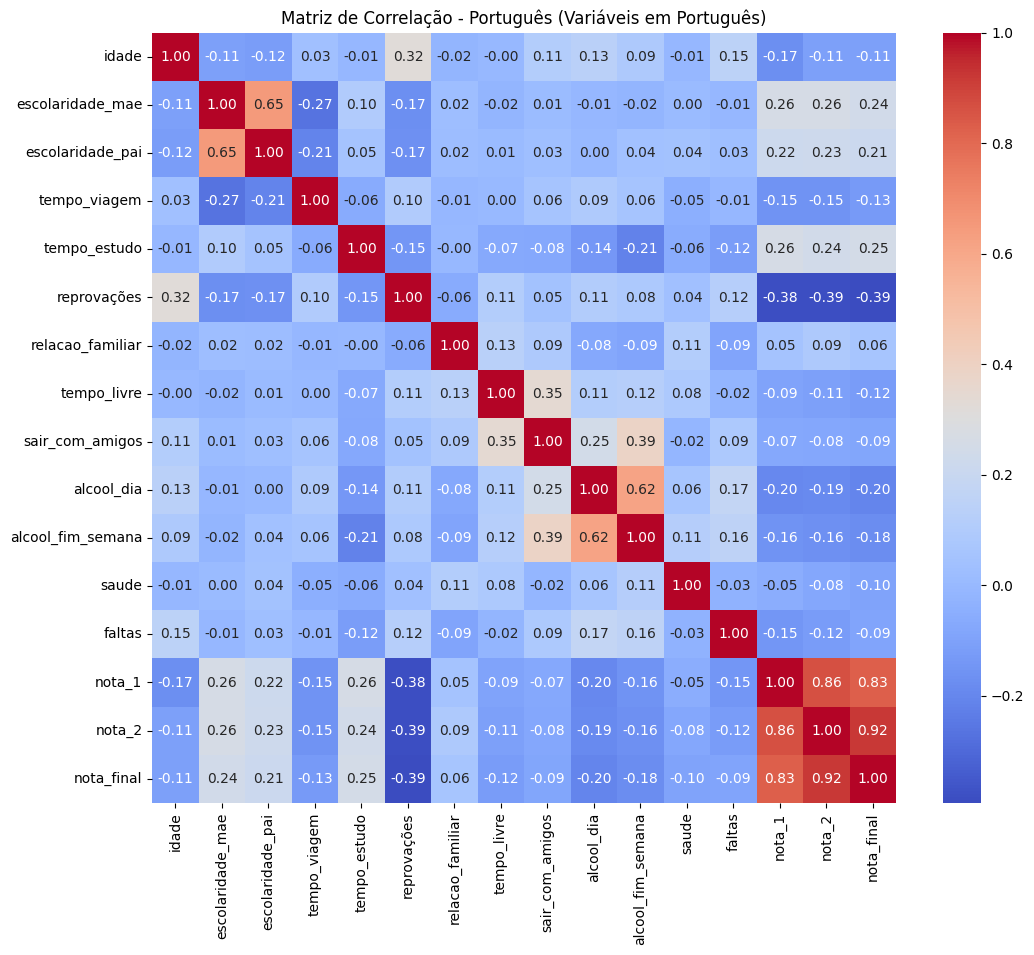

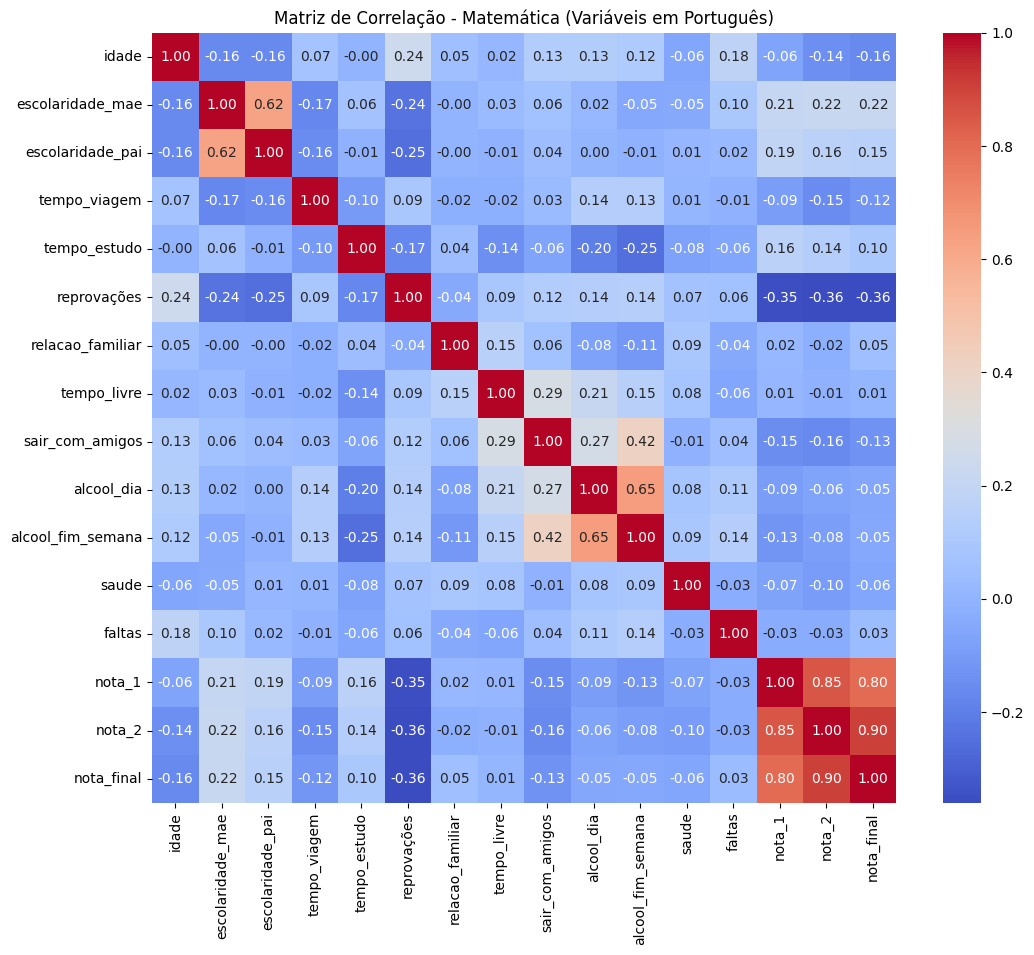

In [11]:
# Matriz de correlação para português com nomes em português
corr_por = df_por.select_dtypes(include=[np.number]).corr()
corr_por_pt = corr_por.rename(index=traducao, columns=traducao)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_por_pt, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Português (Variáveis em Português)')
plt.show()

#------------------------------------------------------------------------------

# Matriz de correlação para matemática com nomes em português
corr_mat = df_mat.select_dtypes(include=[np.number]).corr()
corr_mat_pt = corr_mat.rename(index=traducao, columns=traducao)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat_pt, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Matemática (Variáveis em Português)')
plt.show()


### Tratamento de Dados

In [12]:
def tratar_valores_ausentes(df):
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    return df

def criar_novas_features(df):
    df['media_notas'] = (df['G1'] + df['G2'] + df['G3']) / 3
    df['diff_G1_G2'] = df['G2'] - df['G1']
    df['diff_G2_G3'] = df['G3'] - df['G2']
    df['aprovado'] = (df['G3'] >= 10).astype(int)
    return df

def preparar_dados_modelagem(df):
        le = LabelEncoder()
        for col in df.select_dtypes(include=['object']).columns:
            df[col] = le.fit_transform(df[col])
        scaler = StandardScaler()
        # Não normaliza a coluna 'aprovado'
        colunas_numericas = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'aprovado']
        df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])
        return df

# Aplicando o tratamento
df = df_mat.copy()  # ou df_por.copy()
df = tratar_valores_ausentes(df)
df = criar_novas_features(df)
df = preparar_dados_modelagem(df)

print('Dados tratados e prontos para modelagem!')

Dados tratados e prontos para modelagem!


### Modelagem e Avaliação


Treinando Regressão Logística...
Acurácia: 0.9873417721518988
Precisão: 0.9811320754716981
Recall: 1.0
F1-Score: 0.9904761904761905


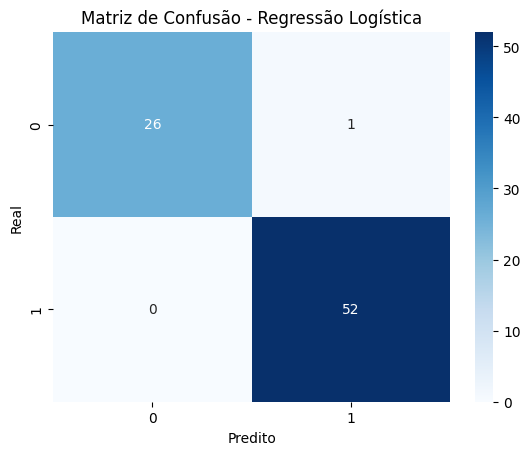


Treinando Random Forest...
Acurácia: 1.0
Precisão: 1.0
Recall: 1.0
F1-Score: 1.0


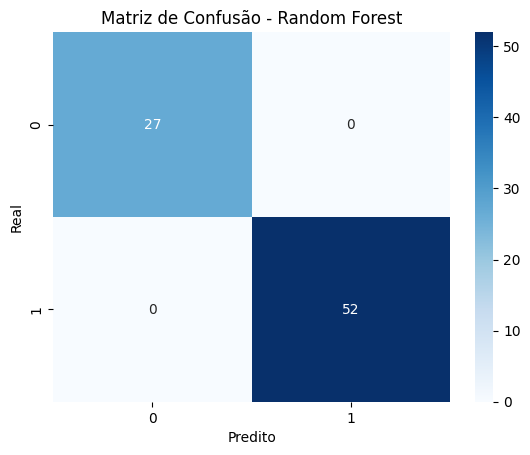


Treinando SVM...
Acurácia: 0.9240506329113924
Precisão: 0.9259259259259259
Recall: 0.9615384615384616
F1-Score: 0.9433962264150944


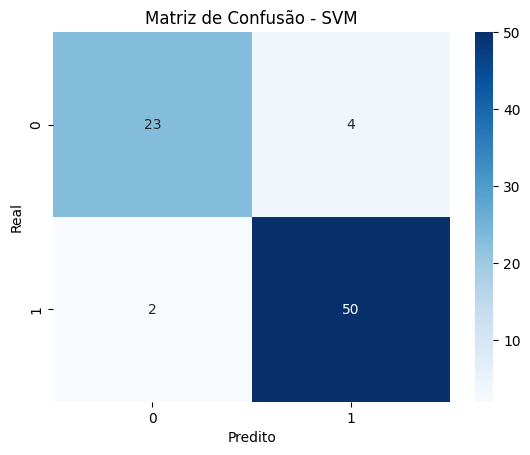

In [13]:
X = df.drop('aprovado', axis=1)
y = df['aprovado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

for nome, modelo in modelos.items():
    print(f'\nTreinando {nome}...')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    print('Acurácia:', accuracy_score(y_test, y_pred))
    print('Precisão:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1-Score:', f1_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()

In [12]:
# # Salve o DataFrame tratado em um arquivo CSV
# df.to_csv('dados_tratados_para_predicao.csv', index=False)
# print("Arquivo CSV salvo com sucesso!")

### Detecção de Outliers - Matemática

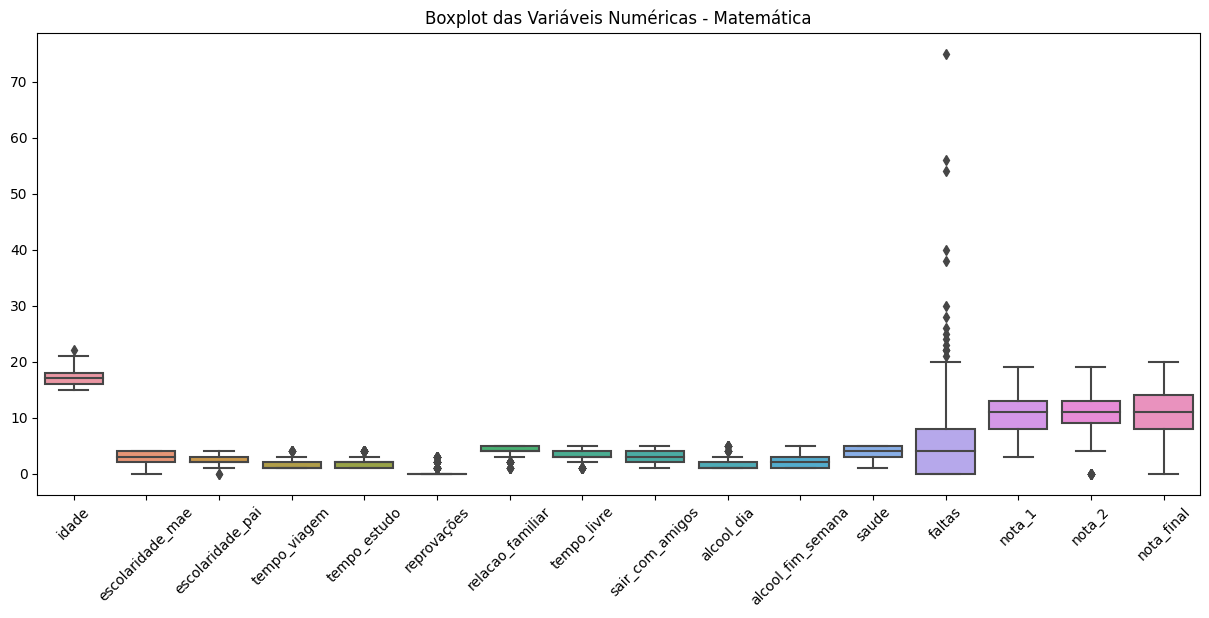

Quantidade de outliers por coluna (Matemática):
{'idade': 1, 'escolaridade_mae': 0, 'escolaridade_pai': 2, 'tempo_viagem': 8, 'tempo_estudo': 27, 'reprovações': 83, 'relacao_familiar': 26, 'tempo_livre': 19, 'sair_com_amigos': 0, 'alcool_dia': 18, 'alcool_fim_semana': 0, 'saude': 0, 'faltas': 15, 'nota_1': 0, 'nota_2': 13, 'nota_final': 0}


In [14]:
# Aplica a tradução das colunas
df_mat_pt = df_mat.rename(columns=traducao)

# Seleciona apenas as colunas numéricas
dados_numericos_mat = df_mat_pt.select_dtypes(include=[np.number])

# Visualização com boxplots (nomes em português)
plt.figure(figsize=(15, 6))
sns.boxplot(data=dados_numericos_mat)
plt.title('Boxplot das Variáveis Numéricas - Matemática')
plt.xticks(rotation=45)
plt.show()

# Detecção estatística usando IQR (nomes em português)
outliers_mat = {}
for col in dados_numericos_mat.columns:
    Q1 = df_mat_pt[col].quantile(0.25)
    Q3 = df_mat_pt[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_mat_pt[(df_mat_pt[col] < Q1 - 1.5 * IQR) | (df_mat_pt[col] > Q3 + 1.5 * IQR)]
    outliers_mat[col] = outliers.shape[0]
print("Quantidade de outliers por coluna (Matemática):")
print(outliers_mat)

### Detecção de Outliers - Português

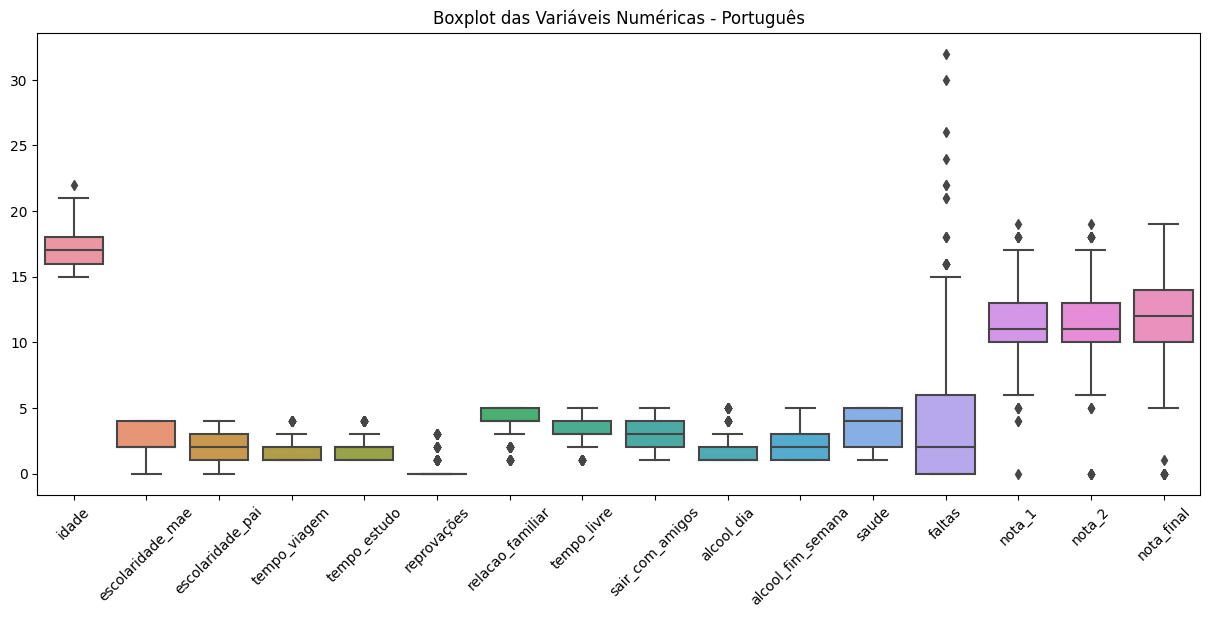

Quantidade de outliers por coluna (Português):
{'idade': 1, 'escolaridade_mae': 0, 'escolaridade_pai': 0, 'tempo_viagem': 16, 'tempo_estudo': 35, 'reprovações': 100, 'relacao_familiar': 51, 'tempo_livre': 45, 'sair_com_amigos': 0, 'alcool_dia': 34, 'alcool_fim_semana': 0, 'saude': 0, 'faltas': 21, 'nota_1': 16, 'nota_2': 25, 'nota_final': 16}


In [15]:
# Aplica a tradução das colunas
df_por_pt = df_por.rename(columns=traducao)

# Seleciona apenas as colunas numéricas
dados_numericos_por = df_por_pt.select_dtypes(include=[np.number])

# Visualização com boxplots (nomes em português)
plt.figure(figsize=(15, 6))
sns.boxplot(data=dados_numericos_por)
plt.title('Boxplot das Variáveis Numéricas - Português')
plt.xticks(rotation=45)
plt.show()

# Detecção estatística usando IQR (nomes em português)
outliers_por = {}
for col in dados_numericos_por.columns:
    Q1 = df_por_pt[col].quantile(0.25)
    Q3 = df_por_pt[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_por_pt[(df_por_pt[col] < Q1 - 1.5 * IQR) | (df_por_pt[col] > Q3 + 1.5 * IQR)]
    outliers_por[col] = outliers.shape[0]
print("Quantidade de outliers por coluna (Português):")
print(outliers_por)

### Tratamento de Valores Ausentes - Matemática

In [16]:
# Preenchendo valores ausentes: numéricas com mediana, categóricas com moda
df_mat_pt = df_mat.rename(columns=traducao).copy()
for col in df_mat_pt.select_dtypes(include=[np.number]).columns:
    df_mat_pt[col].fillna(df_mat_pt[col].median(), inplace=True)
for col in df_mat_pt.select_dtypes(include=['object']).columns:
    df_mat_pt[col].fillna(df_mat_pt[col].mode()[0], inplace=True)
print("Valores ausentes tratados (Matemática).")

Valores ausentes tratados (Matemática).


In [17]:
# Removendo outliers usando IQR
for col in df_mat_pt.select_dtypes(include=[np.number]).columns:
    Q1 = df_mat_pt[col].quantile(0.25)
    Q3 = df_mat_pt[col].quantile(0.75)
    IQR = Q3 - Q1
    filtro = (df_mat_pt[col] >= Q1 - 1.5 * IQR) & (df_mat_pt[col] <= Q3 + 1.5 * IQR)
    df_mat_pt = df_mat_pt[filtro]
print("Outliers removidos (Matemática).")

Outliers removidos (Matemática).


In [18]:
# Codificando variáveis categóricas

le = LabelEncoder()
for col in df_mat_pt.select_dtypes(include=['object']).columns:
    df_mat_pt[col] = le.fit_transform(df_mat_pt[col])
print("Variáveis categóricas codificadas (Matemática).")

Variáveis categóricas codificadas (Matemática).


In [19]:
# Normalizando variáveis numéricas

scaler = StandardScaler()
colunas_numericas = df_mat_pt.select_dtypes(include=[np.number]).columns
df_mat_pt[colunas_numericas] = scaler.fit_transform(df_mat_pt[colunas_numericas])
print("Variáveis numéricas normalizadas (Matemática).")

Variáveis numéricas normalizadas (Matemática).


### Tratamento de Valores Ausentes - Português

In [20]:
# Tratar valores ausentes

df_por_pt = df_por.rename(columns=traducao).copy()
for col in df_por_pt.select_dtypes(include=[np.number]).columns:
    df_por_pt[col].fillna(df_por_pt[col].median(), inplace=True)
for col in df_por_pt.select_dtypes(include=['object']).columns:
    df_por_pt[col].fillna(df_por_pt[col].mode()[0], inplace=True)
print("Valores ausentes tratados (Português).")

Valores ausentes tratados (Português).


In [21]:
# Remover Outlier

for col in df_por_pt.select_dtypes(include=[np.number]).columns:
    Q1 = df_por_pt[col].quantile(0.25)
    Q3 = df_por_pt[col].quantile(0.75)
    IQR = Q3 - Q1
    filtro = (df_por_pt[col] >= Q1 - 1.5 * IQR) & (df_por_pt[col] <= Q3 + 1.5 * IQR)
    df_por_pt = df_por_pt[filtro]
print("Outliers removidos (Português).")

Outliers removidos (Português).


In [22]:
# Codificar variáveis Categóricas

for col in df_por_pt.select_dtypes(include=['object']).columns:
    df_por_pt[col] = le.fit_transform(df_por_pt[col])
print("Variáveis categóricas codificadas (Português).")

Variáveis categóricas codificadas (Português).


In [23]:
# normalisar Variáveis numericas

colunas_numericas = df_por_pt.select_dtypes(include=[np.number]).columns
df_por_pt[colunas_numericas] = scaler.fit_transform(df_por_pt[colunas_numericas])
print("Variáveis numéricas normalizadas (Português).")

Variáveis numéricas normalizadas (Português).


### Seleção e Engenharia de Características - Matemática

Avaliar a importância das variáveis e selecionar as mais importantes

Correlação das variáveis com a nota final (Matemática):
nota_final           1.000000
nota_2               0.966550
nota_1               0.888397
sex                  0.226514
escolaridade_mae     0.198417
escolaridade_pai     0.165747
internet             0.160230
Fjob                 0.133724
Mjob                 0.120988
address              0.115211
relacao_familiar     0.109974
famsize              0.059610
nursery              0.055589
higher               0.052215
activities           0.048889
tempo_livre          0.043548
reason               0.036902
tempo_estudo         0.028525
guardian             0.025804
saude               -0.011738
tempo_viagem        -0.061915
alcool_dia          -0.066816
Pstatus             -0.099856
alcool_fim_semana   -0.108028
paid                -0.108632
romantic            -0.110569
sair_com_amigos     -0.117305
famsup              -0.119432
school              -0.139056
idade               -0.152532
faltas              -0.159092
schoolsup     

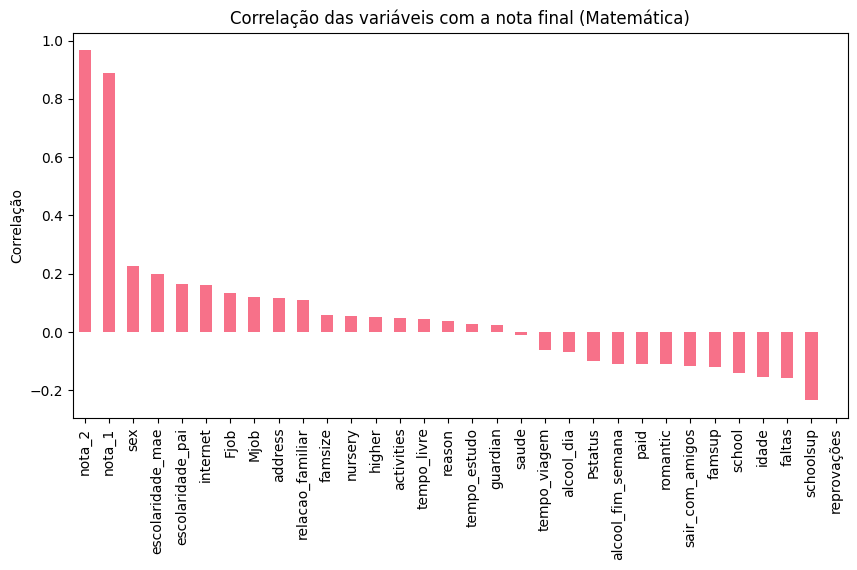

In [24]:
# Verificar a correlação das variáveis com a nota final


correlacoes_mat = df_mat_pt.corr()['nota_final'].sort_values(ascending=False)
print("Correlação das variáveis com a nota final (Matemática):")
print(correlacoes_mat)

# Visualização das correlações
plt.figure(figsize=(10,5))
correlacoes_mat.drop('nota_final').plot(kind='bar')
plt.title('Correlação das variáveis com a nota final (Matemática)')
plt.ylabel('Correlação')
plt.show()

In [25]:
# Novas features
df_mat_pt['media_parcial'] = (df_mat_pt['nota_1'] + df_mat_pt['nota_2']) / 2
df_mat_pt['diferenca_notas'] = df_mat_pt['nota_final'] - df_mat_pt['nota_2']

print("Novas features criadas (Matemática): media_parcial, diferenca_notas")

Novas features criadas (Matemática): media_parcial, diferenca_notas


### Seleção e Engenharia de Características - Português

Avaliar a importância das variáveis e selecionar as mais importantes

Correlação das variáveis com a nota final (Português):
nota_final           1.000000
nota_2               0.942745
nota_1               0.868031
tempo_estudo         0.273280
higher               0.263977
escolaridade_mae     0.238253
address              0.179178
Mjob                 0.171401
escolaridade_pai     0.156799
internet             0.140374
idade                0.113371
Fjob                 0.107219
reason               0.089288
activities           0.082426
nursery              0.058262
relacao_familiar     0.009060
Pstatus             -0.006016
famsup              -0.019087
guardian            -0.027511
romantic            -0.029201
famsize             -0.041233
sair_com_amigos     -0.050261
tempo_viagem        -0.069144
sex                 -0.079537
paid                -0.086568
faltas              -0.107413
tempo_livre         -0.114410
alcool_fim_semana   -0.130609
schoolsup           -0.141925
saude               -0.152493
school              -0.170088
alcool_dia     

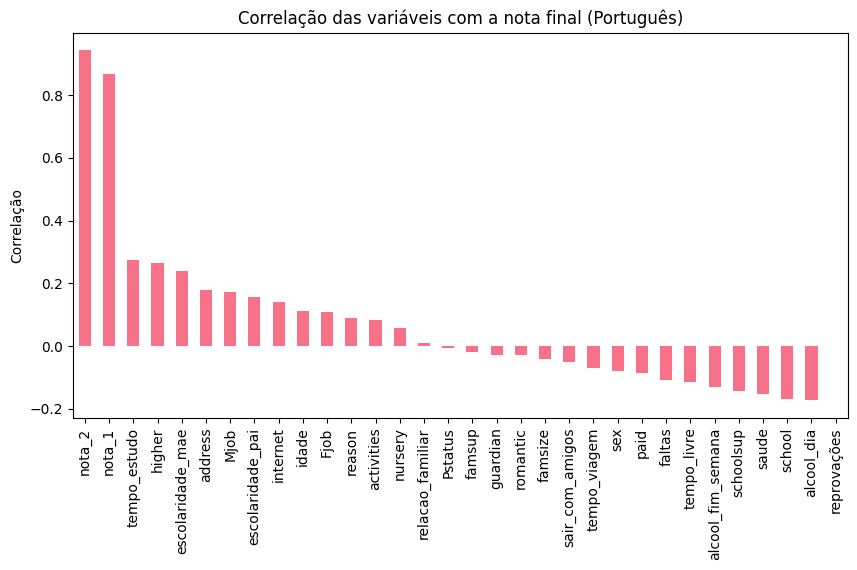

In [26]:
correlacoes_por = df_por_pt.corr()['nota_final'].sort_values(ascending=False)
print("Correlação das variáveis com a nota final (Português):")
print(correlacoes_por)

plt.figure(figsize=(10,5))
correlacoes_por.drop('nota_final').plot(kind='bar')
plt.title('Correlação das variáveis com a nota final (Português)')
plt.ylabel('Correlação')
plt.show()

In [27]:
df_por_pt['media_parcial'] = (df_por_pt['nota_1'] + df_por_pt['nota_2']) / 2
df_por_pt['diferenca_notas'] = df_por_pt['nota_final'] - df_por_pt['nota_2']

print("Novas features criadas (Português): media_parcial, diferenca_notas")

Novas features criadas (Português): media_parcial, diferenca_notas


### Balanceamento de Classes - Matemática

Utilizando SMOTE

In [ ]:
# # Caso o aluno seja 'aprovado'

# X_mat = df_mat_pt.drop('aprovado', axis=1)
# y_mat = df_mat_pt['aprovado']

# print("Distribuição original das classes (Matemática):", Counter(y_mat))

# smote = SMOTE(random_state=42)
# X_mat_res, y_mat_res = smote.fit_resample(X_mat, y_mat)

# print("Distribuição após SMOTE (Matemática):", Counter(y_mat_res))

KeyError: "['aprovado'] not found in axis"

### Balanceamento de Classes - Português

Utilizando SMOTE

In [36]:
# X_por = df_por_pt.drop('aprovado', axis=1)
# y_por = df_por_pt['aprovado']

# print("Distribuição original das classes (Português):", Counter(y_por))

# smote = SMOTE(random_state=42)
# X_por_res, y_por_res = smote.fit_resample(X_por, y_por)

# print("Distribuição após SMOTE (Português):", Counter(y_por_res))

In [37]:
import sys
print(sys.executable)

C:\Users\Casa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


## Random Forest
Implementação do algoritmo de random forest

### Treinar o Modelo Random Forest

In [28]:
# Criar o classificador Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo com os dados de treino
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Fazer previsões

In [29]:
# Prever nos dados de teste
y_pred_rf = rf_model.predict(X_test)

### Avaliar o desempenho

Acurácia: 1.0
Precisão: 1.0
Recall: 1.0
F1 Score: 1.0


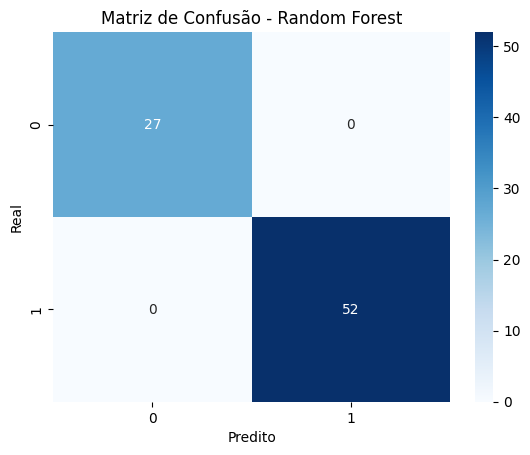

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        52

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# Matriz de confusão
import seaborn as sns
import matplotlib.pyplot as plt

conf_mat = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

# Relatório completo
print(classification_report(y_test, y_pred_rf))


### Validação Cruzada

In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-Validation Accuracy:", scores)
print("Média:", scores.mean())

Cross-Validation Accuracy: [1. 1. 1. 1. 1.]
Média: 1.0


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### POSSIVELMENTE DEU OVERFITTING, VAMO CORRIGIR

Verificação se alguma feature está colada no target

In [33]:
# Adiciona a variável-alvo aos dados de entrada, temporariamente
df_com_target = X.copy()
df_com_target['target'] = y

# Calcula a correlação de Pearson
correlacoes = df_com_target.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlacoes)


target         1.000000
G3             0.770042
media_notas    0.763160
G2             0.725407
G1             0.664979
diff_G2_G3     0.402104
diff_G1_G2     0.264432
higher         0.157708
Medu           0.115396
Fedu           0.108057
reason         0.099300
paid           0.092665
studytime      0.074613
sex            0.070618
internet       0.061791
address        0.052282
famrel         0.046683
famsize        0.041842
Fjob           0.028309
Mjob           0.026592
activities     0.012414
nursery       -0.008784
freetime      -0.018321
Walc          -0.029957
school        -0.031254
Pstatus       -0.044050
traveltime    -0.044446
Dalc          -0.057343
famsup        -0.059219
health        -0.065668
absences      -0.092244
romantic      -0.097737
schoolsup     -0.099860
guardian      -0.101407
age           -0.179645
goout         -0.183399
failures      -0.337731
Name: target, dtype: float64


Remoção de colunas que possam vazar o alvo

In [34]:
# Exemplo: remover colunas suspeitas
X = X.drop(columns=['G3', 'G2'], errors='ignore')  # só se existirem


Split após todas as transformações

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Treinamento da random forest dnv

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Previsões
y_pred = rf_model.predict(X_test)


### Avaliando novamente

              precision    recall  f1-score   support

           0       0.89      0.96      0.93        26
           1       0.98      0.94      0.96        53

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79



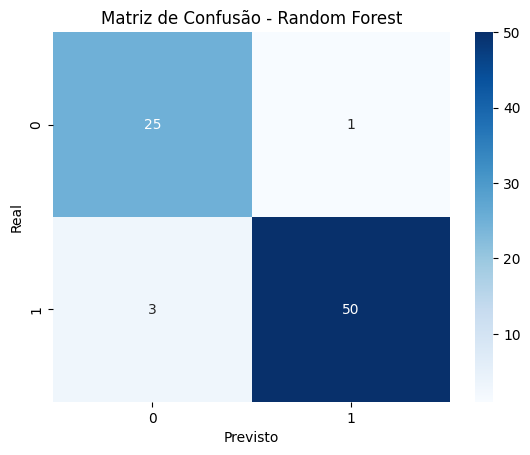

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

# Matriz de confusão
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.show()


Avaliação cruzada pra garantir

In [39]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Média:", scores.mean())

Cross-validation scores: [0.91139241 0.97468354 0.93670886 0.93670886 0.94936709]
Média: 0.9417721518987342


Acurácia:

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.2%}")


Acurácia: 94.94%


Variáveis mais importantes.

        Feature  Importância
31  media_notas     0.405433
30           G1     0.187055
33   diff_G2_G3     0.071447
32   diff_G1_G2     0.039399
14     failures     0.036420
29     absences     0.028051
25        goout     0.021048
8          Mjob     0.013490
24     freetime     0.012635
2           age     0.012040
6          Medu     0.011818
28       health     0.011394
23       famrel     0.010975
27         Walc     0.010887
9          Fjob     0.010739
13    studytime     0.010477
7          Fedu     0.010225
11     guardian     0.009616
10       reason     0.009238
15    schoolsup     0.008167
12   traveltime     0.008095
26         Dalc     0.007949
18   activities     0.006764
20       higher     0.005975
17         paid     0.005364
21     internet     0.004803
3       address     0.004757
1           sex     0.004413
19      nursery     0.004267
16       famsup     0.004038
4       famsize     0.004013
22     romantic     0.003484
5       Pstatus     0.002835
0        schoo

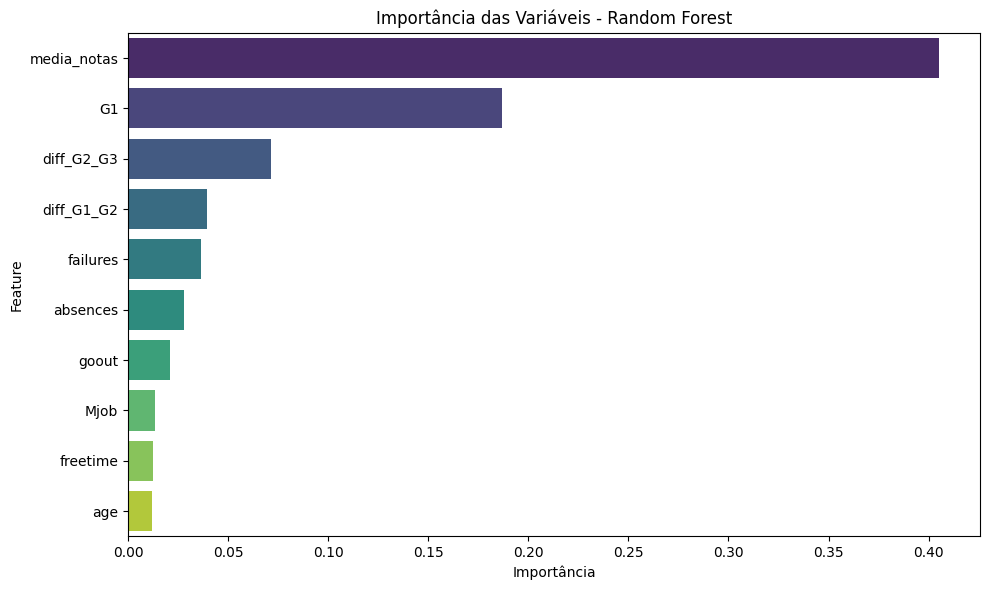

In [ ]:
# Importância das features
importances = rf_model.feature_importances_
features = X.columns

# Ordenar
import pandas as pd
import numpy as np

feat_imp_df = pd.DataFrame({'Feature': features, 'Importância': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importância', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importância', y='Feature', palette='viridis')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
sns.barplot(data=feat_imp_df.head(10), x='Importância', y='Feature', palette='viridis')


# Mostrar tabela
print(feat_imp_df)


#### CURVA ROC

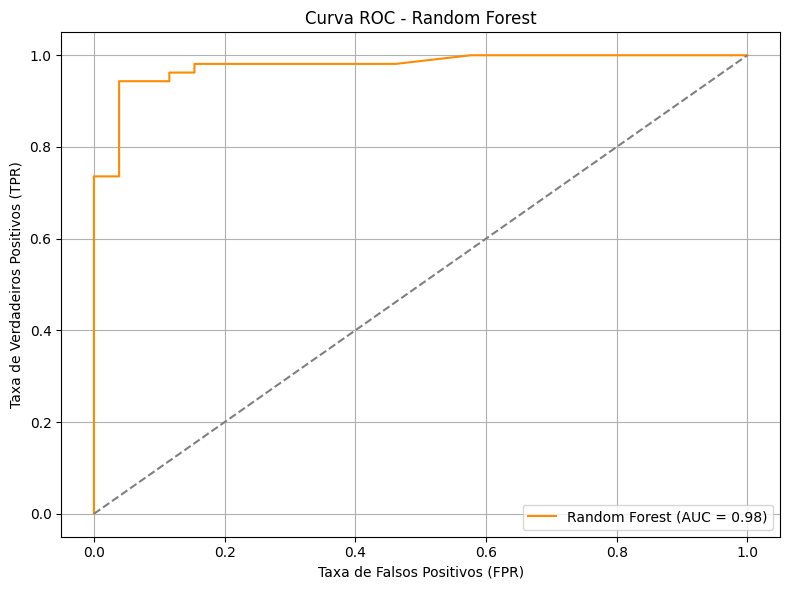

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

# Obter as probabilidades da classe positiva
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calcular a curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plotar a curva
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # linha de referência
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


### AVALIAÇÃO COMPLETA - RANDOM FOREST


Acurácia: 94.94%


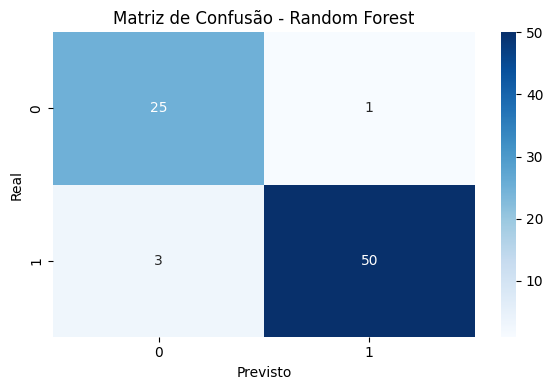


Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93        26
           1       0.98      0.94      0.96        53

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79



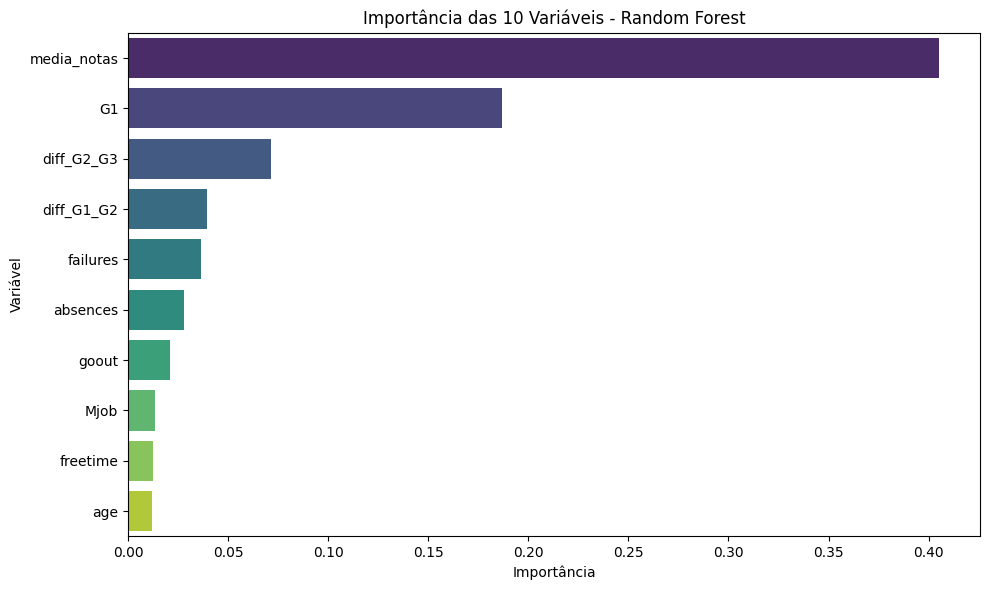


Importância das Variáveis (tabela completa):
        Feature  Importância
31  media_notas     0.405433
30           G1     0.187055
33   diff_G2_G3     0.071447
32   diff_G1_G2     0.039399
14     failures     0.036420
29     absences     0.028051
25        goout     0.021048
8          Mjob     0.013490
24     freetime     0.012635
2           age     0.012040
6          Medu     0.011818
28       health     0.011394
23       famrel     0.010975
27         Walc     0.010887
9          Fjob     0.010739
13    studytime     0.010477
7          Fedu     0.010225
11     guardian     0.009616
10       reason     0.009238
15    schoolsup     0.008167
12   traveltime     0.008095
26         Dalc     0.007949
18   activities     0.006764
20       higher     0.005975
17         paid     0.005364
21     internet     0.004803
3       address     0.004757
1           sex     0.004413
19      nursery     0.004267
16       famsup     0.004038
4       famsize     0.004013
22     romantic     0.0034

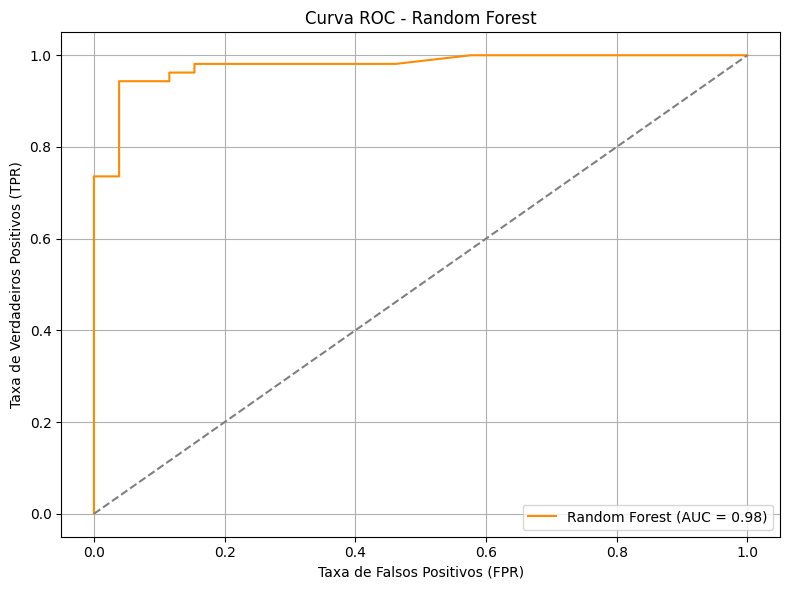

In [53]:
#  Avaliação completa da Random Forest

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1 - Acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.2%}")

# 2 - Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 3 - Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 4 - Importância das Variáveis
importances = rf_model.feature_importances_
features = X.columns

feat_imp_df = pd.DataFrame({'Feature': features, 'Importância': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='Importância', y='Feature', palette='viridis')
plt.title('Importância das 10 Variáveis - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

print("\nImportância das Variáveis (tabela completa):")
print(feat_imp_df)

# 5 - Curva ROC
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()
